# Healthcare Staff Productivity & Shift Analysis

## Capstone Project

### Business Problem

A 500-bed hospital wants to improve workforce planning by analyzing staffing levels, overtime, absenteeism, and staff productivity.

### Objectives

- Identify understaffed departments
- Analyze overtime patterns
- Measure absenteeism
- Evaluate staff workload
- Support data-driven staffing decisions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load all 5 files
Load all five CSV files.

In [2]:
shifts = pd.read_csv(r'D:\Data_Analystics\Capstone_project_gudie\Cleaned_CSV\shifts.csv')
staff = pd.read_csv(r'D:\Data_Analystics\Capstone_project_gudie\Cleaned_CSV\staff.csv')
department = pd.read_csv(r'D:\Data_Analystics\Capstone_project_gudie\Cleaned_CSV\department.csv')
dates = pd.read_csv(r'D:\Data_Analystics\Capstone_project_gudie\Cleaned_CSV\dates.csv')
benchmark = pd.read_csv(r'D:\Data_Analystics\Capstone_project_gudie\Cleaned_CSV\role_benchmark.csv')

#Check row/column counts to confirm all files loaded correctly

In [3]:
print("shifts:", shifts.shape) # expect 200 rows, 10 columns (shift records)
print("staff:", staff.shape) # expect 40 rows, 6 columns (staff members)
print("department:", department.shape) # expect 10 rows, columns (departments)
print("dates:", dates.shape) # expect 365 rows, 7 columns (one per calendar day)
print("role_benchmark:", benchmark.shape) # expect 3 rows, columns (Nurse, Doctor, Technician)

shifts: (200, 10)
staff: (40, 6)
department: (10, 4)
dates: (365, 7)
role_benchmark: (3, 4)


Data Understanding

In [4]:
# staff.head()
# staff.info()
staff.describe(include='all')

,staff_id,staff_name,role,experience_yrs,contract_type,hourly_rate
count,40,40,40,40.000000,40,40.000000
unique,40,40,3,NaN,3,NaN
top,STF001,Anitha Rao,Nurse,NaN,Full-Time,NaN
freq,1,1,20,NaN,29,NaN
mean,NaN,NaN,NaN,9.775000,NaN,381.150000
std,NaN,NaN,NaN,5.318027,NaN,291.865841
min,NaN,NaN,NaN,1.000000,NaN,185.000000
25%,NaN,NaN,NaN,6.000000,NaN,222.500000
50%,NaN,NaN,NaN,9.500000,NaN,254.500000
75%,NaN,NaN,NaN,13.500000,NaN,285.250000


In [5]:
staff.isnull().sum()

staff_id          0
staff_name        0
role              0
experience_yrs    0
contract_type     0
hourly_rate       0
dtype: int64

In [6]:
staff.duplicated().sum()

np.int64(0)

In [7]:
# department.head()
# department.info()
department.describe(include='all')

,dept_id,dept_name,required_staff_per_shift,criticality
count,10,10,10.000000,10
unique,10,10,NaN,3
top,DEPT01,ICU,NaN,Medium
freq,1,1,NaN,5
mean,NaN,NaN,3.100000,NaN
std,NaN,NaN,0.994429,NaN
min,NaN,NaN,2.000000,NaN
25%,NaN,NaN,2.250000,NaN
50%,NaN,NaN,3.000000,NaN
75%,NaN,NaN,3.750000,NaN


In [8]:
department.isnull().sum()

dept_id                     0
dept_name                   0
required_staff_per_shift    0
criticality                 0
dtype: int64

In [9]:
department.duplicated().sum()

np.int64(0)

In [10]:
# dates.head()
# dates.info()
dates.describe(include='all')


,date_id,full_date,day_of_week,month,quarter,year,is_weekend
count,365,365,365,365.000000,365.00000,365.0,365
unique,365,365,7,NaN,NaN,NaN,2
top,DT20240101,01-01-2024,Monday,NaN,NaN,NaN,False
freq,1,1,53,NaN,NaN,NaN,261
mean,NaN,NaN,NaN,6.498630,2.50137,2024.0,NaN
std,NaN,NaN,NaN,3.448702,1.11834,0.0,NaN
min,NaN,NaN,NaN,1.000000,1.00000,2024.0,NaN
25%,NaN,NaN,NaN,4.000000,2.00000,2024.0,NaN
50%,NaN,NaN,NaN,7.000000,3.00000,2024.0,NaN
75%,NaN,NaN,NaN,9.000000,3.00000,2024.0,NaN


In [11]:
dates.isnull().sum()


date_id        0
full_date      0
day_of_week    0
month          0
quarter        0
year           0
is_weekend     0
dtype: int64

In [12]:
dates.duplicated().sum()

np.int64(0)

In [13]:
# benchmark.head()
# benchmark.info()
benchmark.describe(include='all')


,role,max_patients_per_shift,standard_shift_hrs,overtime_threshold_hrs
count,3,3.0,3.0,3.000000
unique,3,NaN,NaN,NaN
top,Nurse,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,10.0,8.0,17.666667
std,NaN,2.0,0.0,2.516611
min,NaN,8.0,8.0,15.000000
25%,NaN,9.0,8.0,16.500000
50%,NaN,10.0,8.0,18.000000
75%,NaN,11.0,8.0,19.000000


In [14]:
benchmark.isnull().sum()


role                      0
max_patients_per_shift    0
standard_shift_hrs        0
overtime_threshold_hrs    0
dtype: int64

In [15]:
benchmark.duplicated().sum()

np.int64(0)

In [16]:
# shifts.head()
# shifts.info()
shifts.describe(include='all')

,shift_id,staff_id,dept_id,date_id,shift_date,shift_type,hours_worked,overtime_hrs,patients_attended,absent_flag
count,200,200,200,200,200,200,200.000000,200.000000,200.000000,200
unique,200,40,10,151,151,3,NaN,NaN,NaN,2
top,SHF0001,STF026,DEPT01,DT20241122,2024-11-22,Evening,NaN,NaN,NaN,False
freq,1,13,32,4,4,67,NaN,NaN,NaN,168
mean,NaN,NaN,NaN,NaN,NaN,NaN,7.539500,0.819500,7.515000,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,3.408973,0.931563,4.003739,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,0.000000,5.750000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.450000,0.450000,8.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,9.425000,1.425000,10.000000,NaN


In [17]:
shifts.isnull().sum()

shift_id             0
staff_id             0
dept_id              0
date_id              0
shift_date           0
shift_type           0
hours_worked         0
overtime_hrs         0
patients_attended    0
absent_flag          0
dtype: int64

In [18]:
shifts.duplicated().sum()

np.int64(0)

In [19]:
# Check dtype of the date column
print(dates['full_date'].dtype)

object


In [20]:
# Check dtypes of join key columns across all tables
print(staff['staff_id'].dtype)
print(department['dept_id'].dtype)
print(dates['date_id'].dtype)
print(shifts['staff_id'].dtype)
print(shifts['dept_id'].dtype)
print(shifts['date_id'].dtype)

object
object
object
object
object
object


In [21]:
dates['full_date'] = pd.to_datetime(dates['full_date'], format='%d-%m-%Y')

In [22]:
print(dates['full_date'].dtype)

datetime64[ns]


In [23]:
# Check for orphan keys — IDs in shifts.csv that don't exist in the dimension tables
missing_dept = shifts[~shifts["dept_id"].isin(department["dept_id"])]
missing_staff = shifts[~shifts["staff_id"].isin(staff["staff_id"])]
missing_date = shifts[~shifts["date_id"].isin(dates["date_id"])]

print("Shifts with unknown dept_id:", len(missing_dept))
print("Shifts with unknown staff_id:", len(missing_staff))
print("Shifts with unknown date_id:", len(missing_date))

Shifts with unknown dept_id: 0
Shifts with unknown staff_id: 0
Shifts with unknown date_id: 0


In [24]:
print(staff["role"].unique())
print(benchmark["role"].unique())

['Nurse' 'Doctor' 'Technician']
['Nurse' 'Doctor' 'Technician']


merge

In [25]:
# Start with shifts as the base (it's the fact table — one row per shift worked)
master = shifts.merge(staff, on="staff_id", how="left")
master = master.merge(department, on="dept_id", how="left")
master = master.merge(dates, on="date_id", how="left")
master = master.merge(benchmark, on="role", how="left")

print(master.shape)
master.head()

(200, 27)


,shift_id,staff_id,dept_id,date_id,shift_date,shift_type,hours_worked,overtime_hrs,patients_attended,absent_flag,...,criticality,full_date,day_of_week,month,quarter,year,is_weekend,max_patients_per_shift,standard_shift_hrs,overtime_threshold_hrs
0,SHF0001,STF011,DEPT10,DT20241218,2024-12-18,Evening,9.8,1.8,10,False,...,High,2024-12-18,Wednesday,12,4,2024,False,12,8,20
1,SHF0002,STF039,DEPT04,DT20240617,2024-06-17,Morning,9.7,1.7,7,False,...,Medium,2024-06-17,Monday,6,2,2024,False,10,8,18
2,SHF0003,STF034,DEPT07,DT20240622,2024-06-22,Evening,9.0,1.0,8,False,...,Medium,2024-06-22,Saturday,6,2,2024,True,10,8,18
3,SHF0004,STF017,DEPT05,DT20240112,2024-01-12,Night,8.4,0.4,8,False,...,Low,2024-01-12,Friday,1,1,2024,False,12,8,20
4,SHF0005,STF011,DEPT04,DT20240420,2024-04-20,Morning,8.0,0.0,10,False,...,Medium,2024-04-20,Saturday,4,2,2024,True,12,8,20


In [26]:
master.shape

(200, 27)

In [27]:
master.isnull().sum()

shift_id                    0
staff_id                    0
dept_id                     0
date_id                     0
shift_date                  0
shift_type                  0
hours_worked                0
overtime_hrs                0
patients_attended           0
absent_flag                 0
staff_name                  0
role                        0
experience_yrs              0
contract_type               0
hourly_rate                 0
dept_name                   0
required_staff_per_shift    0
criticality                 0
full_date                   0
day_of_week                 0
month                       0
quarter                     0
year                        0
is_weekend                  0
max_patients_per_shift      0
standard_shift_hrs          0
overtime_threshold_hrs      0
dtype: int64

WHERE: which departments are consistently understaffed
1.Group by department + date + shift_type to count actual staff present per shift
2.Compare that count against the department's required_staff_per_shift
3.Flag which shifts were understaffed, then roll up to "which departments are understaffed most often"

In [28]:
#a: Count actual staff present per shift-instance

# Only count staff who actually showed up (not absent)
present = master[master["absent_flag"] == False]

# Group by department + date + shift_type = one "shift instance"
staffing_actual = present.groupby(["dept_id", "dept_name", "shift_date", "shift_type", "required_staff_per_shift"]).size().reset_index(name="actual_staff")

staffing_actual.head()

,dept_id,dept_name,shift_date,shift_type,required_staff_per_shift,actual_staff
0,DEPT01,ICU,2024-01-16,Night,4,1
1,DEPT01,ICU,2024-01-22,Night,4,1
2,DEPT01,ICU,2024-01-26,Evening,4,1
3,DEPT01,ICU,2024-02-04,Night,4,1
4,DEPT01,ICU,2024-03-03,Evening,4,1


In [29]:
#b: Calculate the staffing gap and flag understaffed instances

staffing_actual["staffing_gap"] = staffing_actual["required_staff_per_shift"] - staffing_actual["actual_staff"]
staffing_actual["understaffed"] = staffing_actual["staffing_gap"] > 0

staffing_actual.head()

,dept_id,dept_name,shift_date,shift_type,required_staff_per_shift,actual_staff,staffing_gap,understaffed
0,DEPT01,ICU,2024-01-16,Night,4,1,3,True
1,DEPT01,ICU,2024-01-22,Night,4,1,3,True
2,DEPT01,ICU,2024-01-26,Evening,4,1,3,True
3,DEPT01,ICU,2024-02-04,Night,4,1,3,True
4,DEPT01,ICU,2024-03-03,Evening,4,1,3,True


In [30]:
#c: Roll up to department level — answer Business Question 1

dept_understaffing = staffing_actual.groupby("dept_name").agg(
    total_shift_instances=("understaffed", "count"),
    understaffed_instances=("understaffed", "sum"),
    avg_staffing_gap=("staffing_gap", "mean")
).reset_index()

dept_understaffing["understaffed_pct"] = (dept_understaffing["understaffed_instances"] / dept_understaffing["total_shift_instances"] * 100).round(1)

dept_understaffing.sort_values("understaffed_pct", ascending=False)

,dept_name,total_shift_instances,understaffed_instances,avg_staffing_gap,understaffed_pct
0,Cardiology,15,15,2.0,100.0
1,Emergency,14,14,4.0,100.0
2,General_Ward,23,23,3.0,100.0
3,ICU,26,26,3.0,100.0
4,Maternity,11,11,2.0,100.0
5,Nephrology,16,16,1.0,100.0
6,Neurology,15,15,1.0,100.0
7,Oncology,12,12,2.0,100.0
8,Orthopaedics,13,13,1.0,100.0
9,Paediatrics,23,23,2.0,100.0


In [31]:
# How many total shift instances exist in the full year across all dept/shift combos?
print("Total possible dept x date x shift_type combos:", 10 * 365 * 3)

# How many actually have ANY record in our data?
print("Combos with at least 1 shift record:", staffing_actual.shape[0])

# Average shifts per department overall
print(master.groupby("dept_name")["shift_id"].count())

Total possible dept x date x shift_type combos: 10950
Combos with at least 1 shift record: 168
dept_name
Cardiology      19
Emergency       18
General_Ward    26
ICU             32
Maternity       14
Nephrology      17
Neurology       16
Oncology        14
Orthopaedics    18
Paediatrics     26
Name: shift_id, dtype: int64


In [32]:
dept_understaffing["total_staffing_deficit"] = staffing_actual.groupby("dept_name")["staffing_gap"].sum().values

dept_understaffing[["dept_name", "total_shift_instances", "avg_staffing_gap", "total_staffing_deficit"]].sort_values("avg_staffing_gap", ascending=False)

,dept_name,total_shift_instances,avg_staffing_gap,total_staffing_deficit
1,Emergency,14,4.0,56
2,General_Ward,23,3.0,69
3,ICU,26,3.0,78
0,Cardiology,15,2.0,30
4,Maternity,11,2.0,22
7,Oncology,12,2.0,24
9,Paediatrics,23,2.0,46
5,Nephrology,16,1.0,16
6,Neurology,15,1.0,15
8,Orthopaedics,13,1.0,13


WHO: Business Question 2 (which staff/roles accumulate the most overtime).

In [45]:
#a: Overtime by individual staff member — build the aggregation

staff_overtime = master.groupby(["staff_id", "staff_name", "role", "contract_type"]).agg(
    total_overtime_hrs=("overtime_hrs", "sum"),
    avg_overtime_per_shift=("overtime_hrs", "mean")
).reset_index()

staff_overtime.head()

,staff_id,staff_name,role,contract_type,total_overtime_hrs,avg_overtime_per_shift
0,STF001,Anitha Rao,Nurse,Full-Time,2.4,1.200000
1,STF002,Preethi Nair,Nurse,Full-Time,1.1,0.275000
2,STF003,Sunita Hegde,Nurse,Full-Time,3.6,0.900000
3,STF004,Kavitha Bhat,Nurse,Full-Time,0.9,0.450000
4,STF005,Rekha Sharma,Nurse,Full-Time,4.3,0.614286


In [46]:
#b: Roll up staff_overtime to role level

role_overtime = staff_overtime.groupby("role").agg(
    total_overtime_hrs=("total_overtime_hrs", "sum"),
    avg_overtime_per_shift=("avg_overtime_per_shift", "mean"),
    overtime_per_staff=("total_overtime_hrs", "mean")
).reset_index()

role_overtime.head()

,role,total_overtime_hrs,avg_overtime_per_shift,overtime_per_staff
0,Doctor,40.4,0.938269,5.050
1,Nurse,78.8,0.737894,3.940
2,Technician,44.7,0.702520,3.725


WHEN: Business Question 3 — absenteeism by department, and which weekday it peaks on.

In [47]:
#a: Absenteeism rate by department

dept_absence = master.groupby("dept_name").agg(
    total_shifts=("shift_id", "count"),
    absent_shifts=("absent_flag", "sum")
).reset_index()

dept_absence["absenteeism_rate_pct"] = (dept_absence["absent_shifts"] / dept_absence["total_shifts"] * 100).round(1)
dept_absence.sort_values("absenteeism_rate_pct", ascending=False)

,dept_name,total_shifts,absent_shifts,absenteeism_rate_pct
8,Orthopaedics,18,5,27.8
1,Emergency,18,4,22.2
4,Maternity,14,3,21.4
0,Cardiology,19,4,21.1
3,ICU,32,6,18.8
7,Oncology,14,2,14.3
2,General_Ward,26,3,11.5
9,Paediatrics,26,3,11.5
6,Neurology,16,1,6.2
5,Nephrology,17,1,5.9


In [48]:
#b: Absenteeism by day of week

weekday_order = {
    "Monday": 1, "Tuesday": 2, "Wednesday": 3, "Thursday": 4,
    "Friday": 5, "Saturday": 6, "Sunday": 7
}

master["day_of_week_num"] = master["day_of_week"].map(weekday_order)

weekday_absence = master.groupby(["day_of_week", "day_of_week_num"]).agg(
    total_shifts=("shift_id", "count"),
    absent_shifts=("absent_flag", "sum")
).reset_index()

weekday_absence["absenteeism_rate_pct"] = (weekday_absence["absent_shifts"] / weekday_absence["total_shifts"] * 100).round(1)
weekday_absence = weekday_absence.sort_values("day_of_week_num")

weekday_absence

,day_of_week,day_of_week_num,total_shifts,absent_shifts,absenteeism_rate_pct
1,Monday,1,32,6,18.8
5,Tuesday,2,22,3,13.6
6,Wednesday,3,28,4,14.3
4,Thursday,4,28,2,7.1
0,Friday,5,29,7,24.1
2,Saturday,6,36,5,13.9
3,Sunday,7,25,5,20.0


Business Question 4: patient workload per staff member, and whether it's evenly distributed

In [49]:
#a: Workload per staff member

staff_workload = master.groupby(["staff_id", "staff_name", "role"]).agg(
    total_patients=("patients_attended", "sum"),
    shifts_worked=("shift_id", "count"),
    avg_patients_per_shift=("patients_attended", "mean")
).reset_index()

staff_workload["avg_patients_per_shift"] = staff_workload["avg_patients_per_shift"].round(1)
staff_workload = staff_workload.sort_values("avg_patients_per_shift", ascending=False)
staff_workload.head(10)

,staff_id,staff_name,role,total_patients,shifts_worked,avg_patients_per_shift
8,STF009,Vidya Patil,Nurse,12,1,12.0
15,STF016,Savitha Gowda,Nurse,47,4,11.8
11,STF012,Asha Kulkarni,Nurse,35,3,11.7
0,STF001,Anitha Rao,Nurse,23,2,11.5
7,STF008,Meena Iyer,Nurse,56,5,11.2
13,STF014,Latha Pillai,Nurse,33,3,11.0
3,STF004,Kavitha Bhat,Nurse,22,2,11.0
10,STF011,Swathi Nayak,Nurse,65,6,10.8
19,STF020,Manjula Shetty,Nurse,64,6,10.7
16,STF017,Uma Rajan,Nurse,91,9,10.1


In [50]:
#b: Check evenness — spread by role

workload_spread = master.groupby("role")["patients_attended"].agg(
    mean_patients="mean",
    std_patients="std",
    min_patients="min",
    max_patients="max"
).reset_index()

workload_spread["mean_patients"] = workload_spread["mean_patients"].round(1)
workload_spread["std_patients"] = workload_spread["std_patients"].round(1)

workload_spread

,role,mean_patients,std_patients,min_patients,max_patients
0,Doctor,5.0,3.0,0,11
1,Nurse,9.2,3.7,0,15
2,Technician,6.5,3.8,0,12


In [51]:
master["over_benchmark"] = master["patients_attended"] > master["max_patients_per_shift"]
print(master["over_benchmark"].sum(), "shifts exceeded the role's max recommended patient load")
master[master["over_benchmark"]][["staff_name", "role", "patients_attended", "max_patients_per_shift"]]

15 shifts exceeded the role's max recommended patient load


,staff_name,role,patients_attended,max_patients_per_shift
13,Chitra Murthy,Nurse,13,12
19,Dr. Deepak Nair,Doctor,11,8
30,Chitra Murthy,Nurse,14,12
42,Swathi Nayak,Nurse,14,12
63,Nagaraj Patil,Technician,12,10
103,Dinesh Raju,Technician,11,10
108,Dr. Arun Menon,Doctor,9,8
109,Savitha Gowda,Nurse,15,12
120,Kavitha Bhat,Nurse,14,12
125,Swathi Nayak,Nurse,14,12


Business Question 5 — which shift type is most understaffed AND has the highest overtime

In [52]:
#a: Understaffing by shift type

shift_understaffing = staffing_actual.groupby("shift_type").agg(
    total_shift_instances=("understaffed", "count"),
    understaffed_instances=("understaffed", "sum"),
    avg_staffing_gap=("staffing_gap", "mean"),
    total_staffing_deficit=("staffing_gap", "sum")
).reset_index()

shift_understaffing["avg_staffing_gap"] = shift_understaffing["avg_staffing_gap"].round(1)
shift_understaffing.sort_values("avg_staffing_gap", ascending=False)

,shift_type,total_shift_instances,understaffed_instances,avg_staffing_gap,total_staffing_deficit
1,Morning,57,57,2.3,130
2,Night,53,53,2.3,121
0,Evening,58,58,2.0,118


In [53]:
#b: Overtime by shift type

shift_overtime = master.groupby("shift_type").agg(
    total_overtime_hrs=("overtime_hrs", "sum"),
    avg_overtime_per_shift=("overtime_hrs", "mean"),
    shifts_count=("shift_id", "count")
).reset_index()

shift_overtime["total_overtime_hrs"] = shift_overtime["total_overtime_hrs"].round(0).astype(int)
shift_overtime["avg_overtime_per_shift"] = shift_overtime["avg_overtime_per_shift"].round(2)
shift_overtime.sort_values("avg_overtime_per_shift", ascending=False)

,shift_type,total_overtime_hrs,avg_overtime_per_shift,shifts_count
0,Evening,58,0.87,67
1,Morning,55,0.84,66
2,Night,50,0.75,67


In [54]:
shift_workload = master.groupby("shift_type")["patients_attended"].mean().round(1).reset_index()
shift_workload.sort_values("patients_attended", ascending=False)

,shift_type,patients_attended
0,Evening,7.7
1,Morning,7.7
2,Night,7.2


In [55]:
shift_contract_mix = master.groupby(["shift_type", "contract_type"]).size().unstack(fill_value=0)
shift_contract_mix

contract_type,Contract,Full-Time,Part-Time
shift_type,,,
Evening,10,48,9
Morning,9,53,4
Night,13,43,11


Business Question 6 — overtime cost per department

In [56]:
master["overtime_cost"] = master["overtime_hrs"] * master["hourly_rate"]

dept_overtime_cost = master.groupby("dept_name").agg(
    total_overtime_cost=("overtime_cost", "sum"),
    total_overtime_hrs=("overtime_hrs", "sum")
).reset_index()

dept_overtime_cost["total_overtime_cost"] = dept_overtime_cost["total_overtime_cost"].round(0).astype(int)
dept_overtime_cost = dept_overtime_cost.sort_values("total_overtime_cost", ascending=False)
dept_overtime_cost

,dept_name,total_overtime_cost,total_overtime_hrs
9,Paediatrics,11298,26.5
2,General_Ward,10834,25.8
8,Orthopaedics,9229,16.9
0,Cardiology,8546,19.9
3,ICU,7929,16.7
6,Neurology,6015,16.4
4,Maternity,4388,13.0
1,Emergency,4109,11.4
5,Nephrology,3248,9.4
7,Oncology,1813,7.9


In [57]:
dept_role_mix = master.groupby(["dept_name", "role"]).size().unstack(fill_value=0)
dept_role_mix.loc[["Paediatrics", "General_Ward", "Emergency", "ICU"]]

role,Doctor,Nurse,Technician
dept_name,,,
Paediatrics,4,12,10
General_Ward,5,13,8
Emergency,6,5,7
ICU,7,16,9


Q7: are contract/part-time staff covering gaps that should be filled by full-time employees?

In [58]:
#Contract type reliance analysis

contract_reliance = master.groupby(["dept_name", "contract_type"]).size().unstack(fill_value=0)
contract_reliance["total"] = contract_reliance.sum(axis=1)
contract_reliance["contract_pct"] = ((contract_reliance.get("Contract", 0) + contract_reliance.get("Part-Time", 0)) / contract_reliance["total"] * 100).round(1)
contract_reliance.sort_values("contract_pct", ascending=False)

contract_type,Contract,Full-Time,Part-Time,total,contract_pct
dept_name,,,,,
Cardiology,5,8,6,19,57.9
Oncology,3,9,2,14,35.7
General_Ward,6,18,2,26,30.8
Paediatrics,3,18,5,26,30.8
Orthopaedics,1,13,4,18,27.8
ICU,6,24,2,32,25.0
Emergency,3,14,1,18,22.2
Neurology,1,13,2,16,18.8
Nephrology,3,14,0,17,17.6


In [59]:
dept_summary = dept_understaffing[["dept_name", "avg_staffing_gap", "total_staffing_deficit"]].merge(
    dept_absence[["dept_name", "absenteeism_rate_pct"]], on="dept_name"
).merge(
    dept_overtime_cost[["dept_name", "total_overtime_cost"]], on="dept_name"
).merge(
    contract_reliance[["contract_pct"]].reset_index(), on="dept_name"
).merge(
    department[["dept_name", "criticality"]], on="dept_name"
)

dept_summary

,dept_name,avg_staffing_gap,total_staffing_deficit,absenteeism_rate_pct,total_overtime_cost,contract_pct,criticality
0,Cardiology,2.0,30,21.1,8546,57.9,High
1,Emergency,4.0,56,22.2,4109,22.2,High
2,General_Ward,3.0,69,11.5,10834,30.8,Low
3,ICU,3.0,78,18.8,7929,25.0,High
4,Maternity,2.0,22,21.4,4388,7.1,Medium
5,Nephrology,1.0,16,5.9,3248,17.6,Medium
6,Neurology,1.0,15,6.2,6015,18.8,High
7,Oncology,2.0,24,14.3,1813,35.7,Medium
8,Orthopaedics,1.0,13,27.8,9229,27.8,Medium
9,Paediatrics,2.0,46,11.5,11298,30.8,Medium


In [60]:
corr_cols = ["avg_staffing_gap", "total_staffing_deficit", "absenteeism_rate_pct", "total_overtime_cost", "contract_pct"]
dept_summary[corr_cols].corr().round(2)

,avg_staffing_gap,total_staffing_deficit,absenteeism_rate_pct,total_overtime_cost,contract_pct
avg_staffing_gap,1.00,0.84,0.29,0.06,0.07
total_staffing_deficit,0.84,1.00,0.06,0.41,0.11
absenteeism_rate_pct,0.29,0.06,1.00,0.11,0.17
total_overtime_cost,0.06,0.41,0.11,1.00,0.36
contract_pct,0.07,0.11,0.17,0.36,1.00


In [61]:
dept_summary.groupby("criticality")[corr_cols].mean().round(2)

,avg_staffing_gap,total_staffing_deficit,absenteeism_rate_pct,total_overtime_cost,contract_pct
criticality,,,,,
High,2.5,44.75,17.08,6649.75,30.98
Low,3.0,69.00,11.50,10834.00,30.80
Medium,1.6,24.20,16.18,5995.20,23.80


In [62]:
#Impact summary for the flagged departments

high_crit_impact = master[master["dept_name"].isin(["Cardiology", "Emergency", "ICU", "Neurology"])].groupby("dept_name").agg(
    total_overtime_cost=("overtime_cost", "sum"),
    total_shifts_affected=("shift_id", "count"),
    benchmark_violations=("over_benchmark", "sum")
).reset_index()

high_crit_impact["total_overtime_cost"] = high_crit_impact["total_overtime_cost"].round(0).astype(int)

# Add staffing deficit for reference
high_crit_impact = high_crit_impact.merge(
    dept_understaffing[["dept_name", "total_staffing_deficit"]], on="dept_name"
)

high_crit_impact.sort_values("total_staffing_deficit", ascending=False)

,dept_name,total_overtime_cost,total_shifts_affected,benchmark_violations,total_staffing_deficit
2,ICU,7929,32,3,78
1,Emergency,4109,18,0,56
0,Cardiology,8546,19,3,30
3,Neurology,6015,16,2,15


Chart 1: Q1 finding (severity vs volume by department)

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

dept_sorted = dept_understaffing.sort_values("avg_staffing_gap", ascending=False)

ax1.bar(dept_sorted["dept_name"], dept_sorted["avg_staffing_gap"], color="#4C72B0", label="Avg Staffing Gap")
ax1.set_ylabel("Avg Staffing Gap (per shift)")
ax1.set_xlabel("Department")
ax1.set_xticklabels(dept_sorted["dept_name"], rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(dept_sorted["dept_name"], dept_sorted["total_staffing_deficit"], color="#C44E52", marker="o", label="Total Deficit")
ax2.set_ylabel("Total Staffing Deficit")

fig.suptitle("Department Understaffing: Severity (bars) vs Total Volume (line)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

Chart 2: Overtime — total hours by role vs per-person burden 
(Q2's key finding: Doctors carry the highest per-person burden despite having the fewest total hours).

NameError: name 'role_overtime_display' is not defined

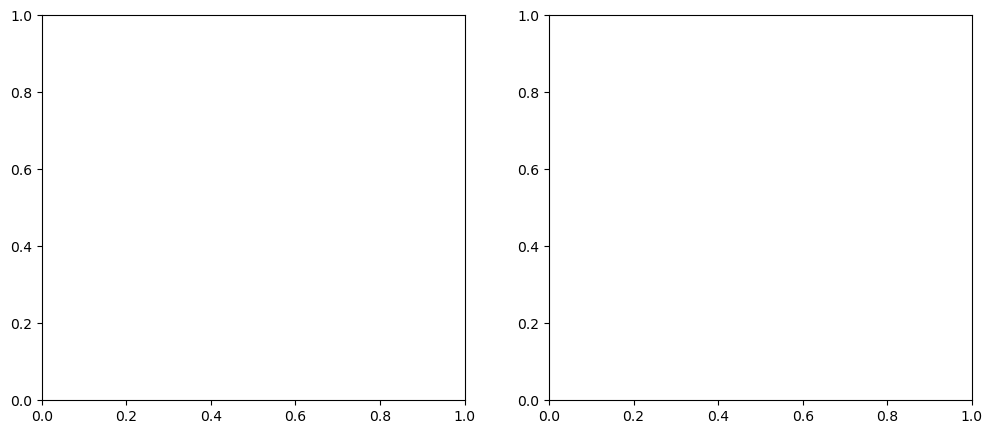

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: total overtime hours by role
axes[0].bar(role_overtime_display["role"], role_overtime_display["total_overtime_hrs"], color="#55A868")
axes[0].set_title("Total Overtime Hours by Role")
axes[0].set_ylabel("Total Overtime Hours")

# Right: overtime per staff member by role
axes[1].bar(role_overtime_display["role"], role_overtime_display["overtime_per_staff"], color="#C44E52")
axes[1].set_title("Overtime per Staff Member by Role")
axes[1].set_ylabel("Overtime Hours per Person")

fig.suptitle("Overtime by Role: Total Volume vs Individual Burden")
plt.tight_layout()
plt.show()

Chart 3: Absenteeism — by department and by weekday (Q3's two findings: department ranking + Friday/weekend clustering)

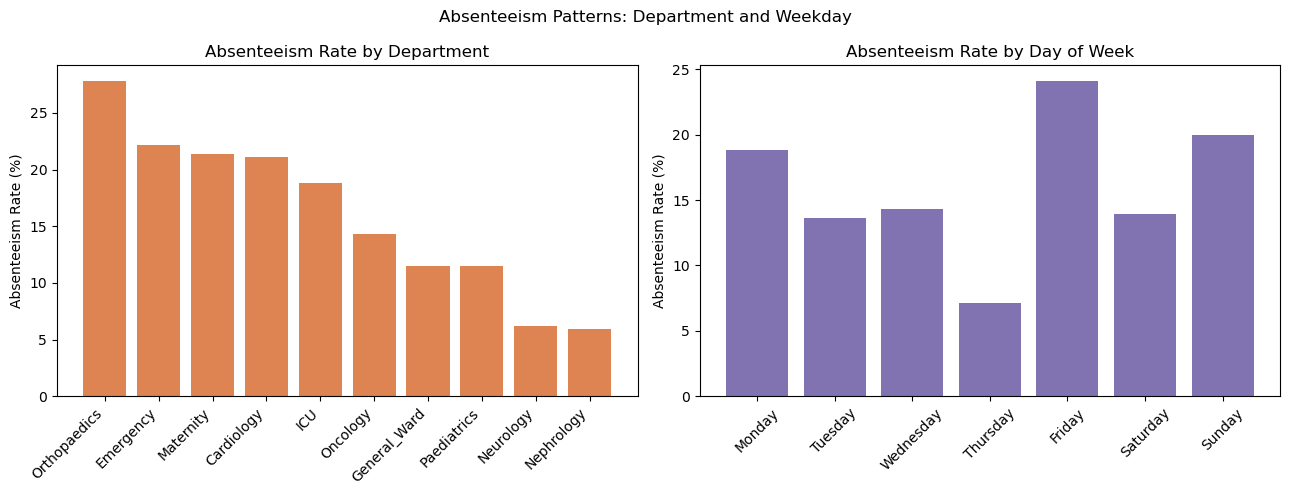

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absenteeism rate by department
dept_absence_sorted = dept_absence.sort_values("absenteeism_rate_pct", ascending=False)
axes[0].bar(dept_absence_sorted["dept_name"], dept_absence_sorted["absenteeism_rate_pct"], color="#DD8452")
axes[0].set_title("Absenteeism Rate by Department")
axes[0].set_ylabel("Absenteeism Rate (%)")
axes[0].tick_params(axis='x', rotation=45)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

# Right: absenteeism rate by weekday, in correct Mon-Sun order
weekday_sorted = weekday_absence.sort_values("day_of_week_num")
axes[1].bar(weekday_sorted["day_of_week"], weekday_sorted["absenteeism_rate_pct"], color="#8172B2")
axes[1].set_title("Absenteeism Rate by Day of Week")
axes[1].set_ylabel("Absenteeism Rate (%)")
axes[1].tick_params(axis='x', rotation=45)

fig.suptitle("Absenteeism Patterns: Department and Weekday")
plt.tight_layout()
plt.show()

Chart 4: Workload evenness — patient load spread by role (Q4's finding: coefficient of variation matters more than raw std)

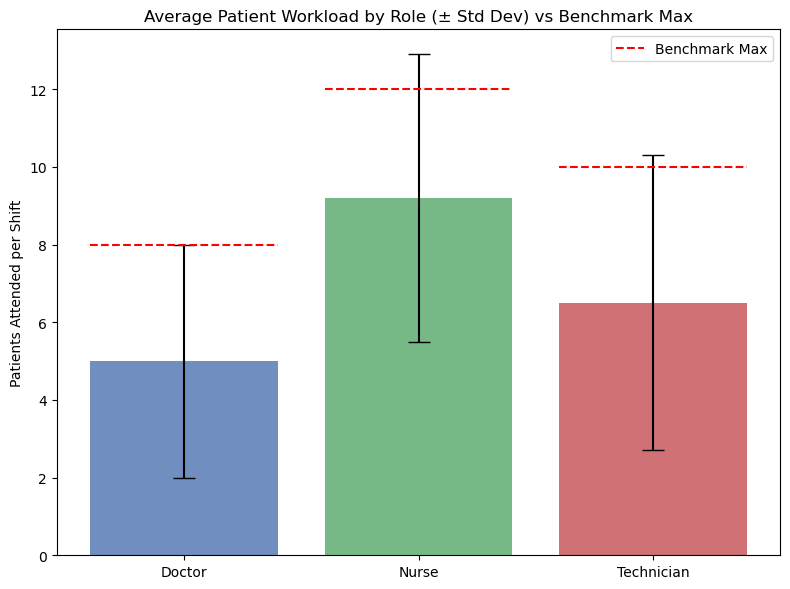

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))

roles = workload_spread["role"]
means = workload_spread["mean_patients"]
stds = workload_spread["std_patients"]

bars = ax.bar(roles, means, yerr=stds, capsize=8, color=["#4C72B0", "#55A868", "#C44E52"], alpha=0.8)

# Overlay benchmark max as a marker per role
benchmarks = benchmark.set_index("role")["max_patients_per_shift"]
for i, r in enumerate(roles):
    ax.hlines(benchmarks[r], i - 0.4, i + 0.4, colors="red", linestyles="dashed",
              label="Benchmark Max" if i == 0 else "")

ax.set_ylabel("Patients Attended per Shift")
ax.set_title("Average Patient Workload by Role (± Std Dev) vs Benchmark Max")
ax.legend()
plt.tight_layout()
plt.show()

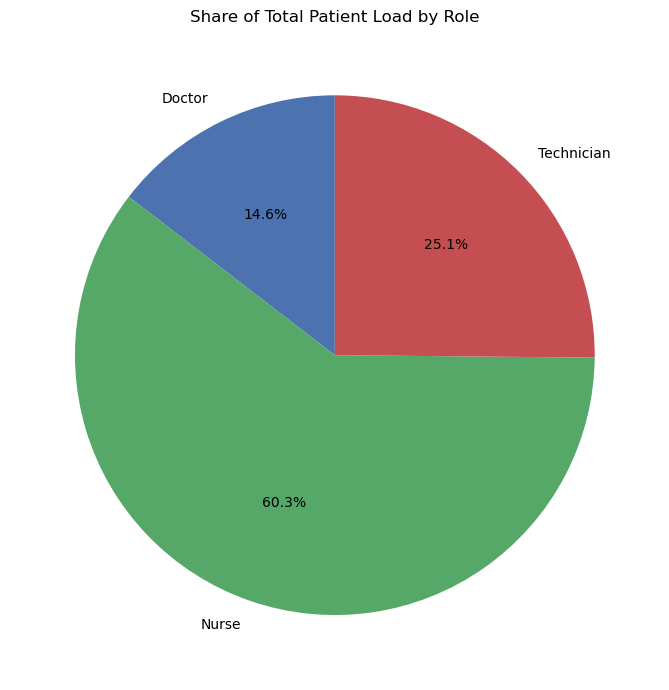

In [66]:
fig, ax = plt.subplots(figsize=(7, 7))

role_totals = master.groupby("role")["patients_attended"].sum()

ax.pie(role_totals, labels=role_totals.index, autopct="%1.1f%%",
       colors=["#4C72B0", "#55A868", "#C44E52"], startangle=90)
ax.set_title("Share of Total Patient Load by Role")
plt.tight_layout()
plt.show()

Chart 5: Shift type comparison — staffing gap vs overtime (Q5's finding: Evening has highest overtime despite not being most understaffed)

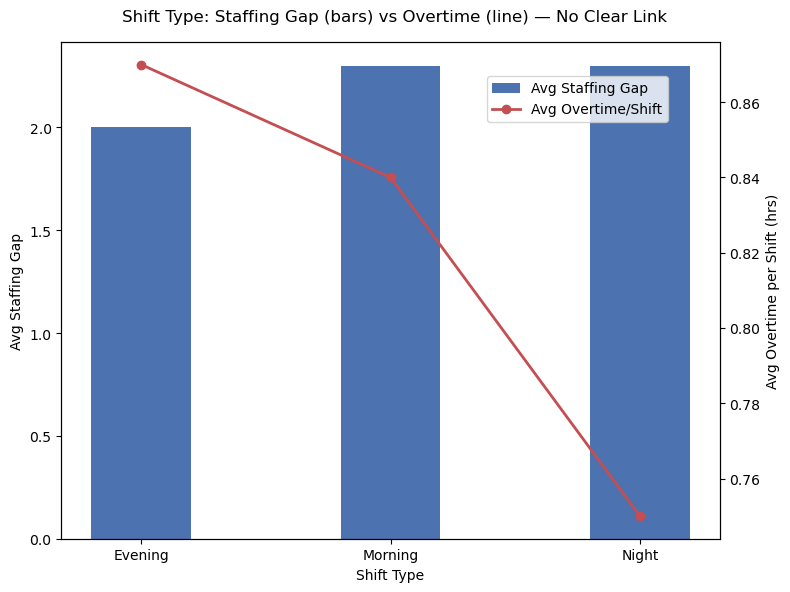

In [67]:
fig, ax1 = plt.subplots(figsize=(8, 6))

shift_order = shift_understaffing.sort_values("shift_type")

x = range(len(shift_order))
ax1.bar(x, shift_order["avg_staffing_gap"], width=0.4, color="#4C72B0", label="Avg Staffing Gap")
ax1.set_xticks(x)
ax1.set_xticklabels(shift_order["shift_type"])
ax1.set_ylabel("Avg Staffing Gap")
ax1.set_xlabel("Shift Type")

ax2 = ax1.twinx()
shift_ot_order = shift_overtime.set_index("shift_type").loc[shift_order["shift_type"]].reset_index()
ax2.plot(x, shift_ot_order["avg_overtime_per_shift"], color="#C44E52", marker="o", linewidth=2, label="Avg Overtime/Shift")
ax2.set_ylabel("Avg Overtime per Shift (hrs)")

fig.suptitle("Shift Type: Staffing Gap (bars) vs Overtime (line) — No Clear Link")
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.88))
plt.tight_layout()
plt.show()

Chart 6: Overtime cost by department (Q6's finding: Paediatrics/General_Ward top the cost list, disconnected from Q1's severity leaders)

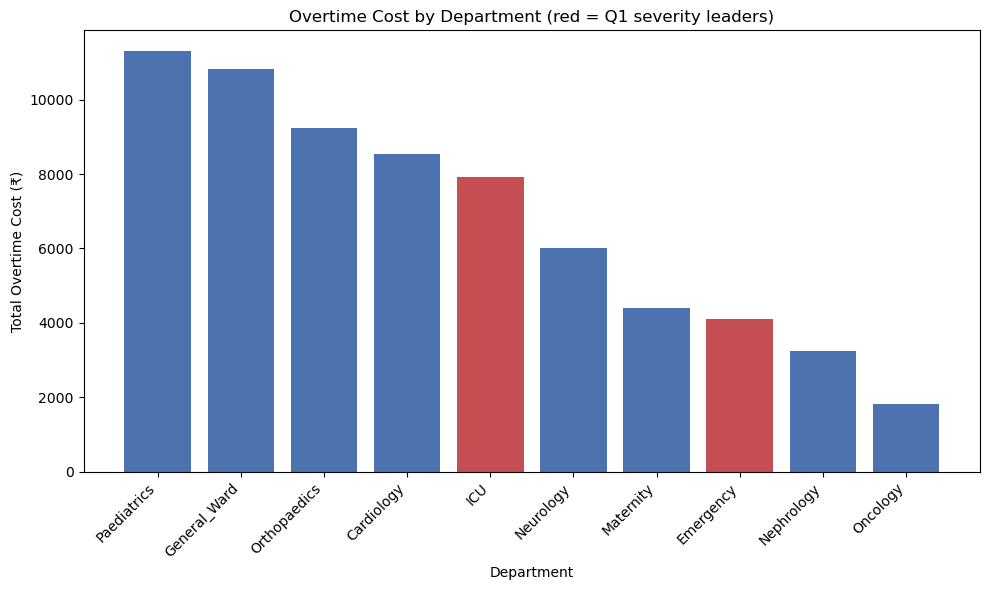

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

cost_sorted = dept_overtime_cost.sort_values("total_overtime_cost", ascending=False)

colors = ["#C44E52" if d in ["Emergency", "ICU"] else "#4C72B0" for d in cost_sorted["dept_name"]]

ax.bar(cost_sorted["dept_name"], cost_sorted["total_overtime_cost"], color=colors)
ax.set_ylabel("Total Overtime Cost (₹)")
ax.set_xlabel("Department")
ax.set_title("Overtime Cost by Department (red = Q1 severity leaders)")
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

plt.tight_layout()
plt.show()

Chart 7: Contract/Part-Time reliance by department (Q7's finding: Cardiology tops reliance, but Emergency/ICU — the real crisis departments — are mostly Full-Time)

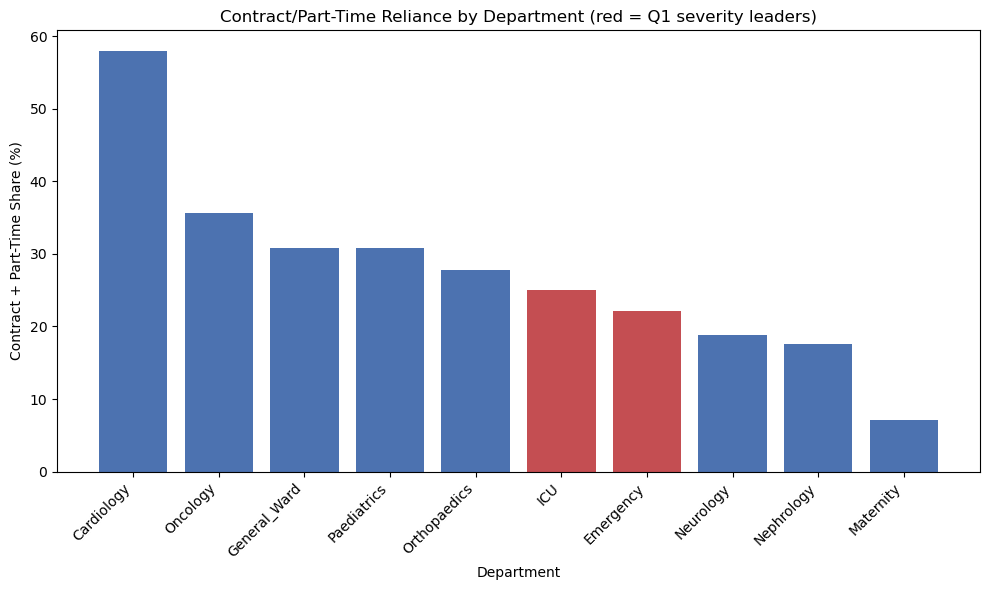

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

reliance_sorted = contract_reliance.reset_index().sort_values("contract_pct", ascending=False)

colors = ["#C44E52" if d in ["Emergency", "ICU"] else "#4C72B0" for d in reliance_sorted["dept_name"]]

ax.bar(reliance_sorted["dept_name"], reliance_sorted["contract_pct"], color=colors)
ax.set_ylabel("Contract + Part-Time Share (%)")
ax.set_xlabel("Department")
ax.set_title("Contract/Part-Time Reliance by Department (red = Q1 severity leaders)")
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

plt.tight_layout()
plt.show()

Chart 8: Root cause — criticality vs staffing gap (the payoff chart — this is the one visual that should anchor your whole storyboard)

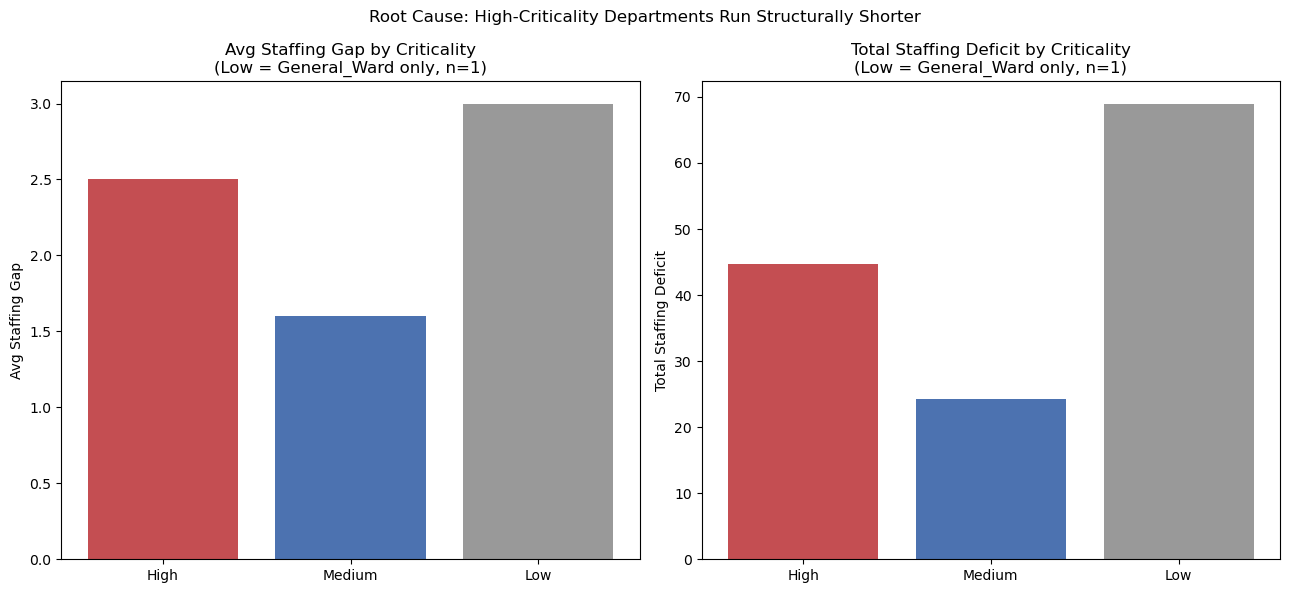

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

crit_order = ["High", "Medium", "Low"]
crit_compare = dept_summary.groupby("criticality")[["avg_staffing_gap", "total_staffing_deficit"]].mean().reindex(crit_order)

# Left: avg staffing gap by criticality group
colors_crit = ["#C44E52", "#4C72B0", "#999999"]
axes[0].bar(crit_compare.index, crit_compare["avg_staffing_gap"], color=colors_crit)
axes[0].set_title("Avg Staffing Gap by Criticality\n(Low = General_Ward only, n=1)")
axes[0].set_ylabel("Avg Staffing Gap")

# Right: total staffing deficit by criticality group
axes[1].bar(crit_compare.index, crit_compare["total_staffing_deficit"], color=colors_crit)
axes[1].set_title("Total Staffing Deficit by Criticality\n(Low = General_Ward only, n=1)")
axes[1].set_ylabel("Total Staffing Deficit")

fig.suptitle("Root Cause: High-Criticality Departments Run Structurally Shorter")
plt.tight_layout()
plt.show()

In [72]:
master.to_csv("hospital_staffs.csv", index=False)